In [28]:
import kagglehub
path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

Using Colab cache for faster access to the 'face-mask-detection' dataset.


In [29]:
!pip install kagglehub opencv-python

import kagglehub
import os

path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

print("Dataset path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Dataset path: /kaggle/input/face-mask-detection
['annotations', 'images']


In [30]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET

data = []
labels = []

IMG_SIZE = 100

annotations_path = os.path.join(path, "annotations")
images_path = os.path.join(path, "images")

for xml_file in os.listdir(annotations_path)[:500]:  # limit for speed
    xml_path = os.path.join(annotations_path, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_file = root.find("filename").text
    img_path = os.path.join(images_path, img_file)

    image = cv2.imread(img_path)

    for obj in root.findall("object"):
        label = obj.find("name").text

        # Map labels
        if label == "with_mask":
            label_id = 0
        else:
            label_id = 1

        bbox = obj.find("bndbox")
        x1 = int(bbox.find("xmin").text)
        y1 = int(bbox.find("ymin").text)
        x2 = int(bbox.find("xmax").text)
        y2 = int(bbox.find("ymax").text)

        face = image[y1:y2, x1:x2]

        try:
            face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
            data.append(face)
            labels.append(label_id)
        except:
            pass

data = np.array(data) / 255.0
labels = np.array(labels)

print("Data:", data.shape)

Data: (2463, 100, 100, 3)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

labels = to_categorical(labels)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353,346 (16.61 MB)

 Trainable params: 4,353,346 (16.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.fit(data, labels, epochs=5, batch_size=32)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8774 - loss: 0.3562
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9423 - loss: 0.1765
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9415 - loss: 0.1705
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9497 - loss: 0.1555
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9423 - loss: 0.1520


In [33]:
model.save('/content/mask_detector.h5')

Saving 61lSJDXuatL._AC_UY1100_.jpg to 61lSJDXuatL._AC_UY1100_ (2).jpg
Saving download.jpg to download (4).jpg
Saving woman-wearing-black-medical-face-mask-looking-camera-quarantine-concept-portrait-woman-wearing-black-medical-face-mask-182155250.webp to woman-wearing-black-medical-face-mask-looking-camera-quarantine-concept-portrait-woman-wearing-black-medical-face-mask-182155250 (3).webp
No face detected → using full image


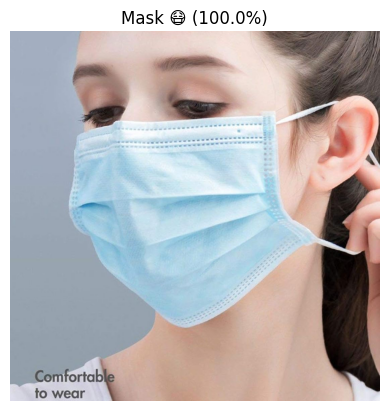

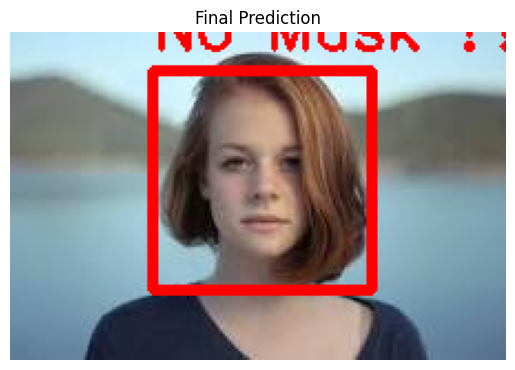

No face detected → using full image


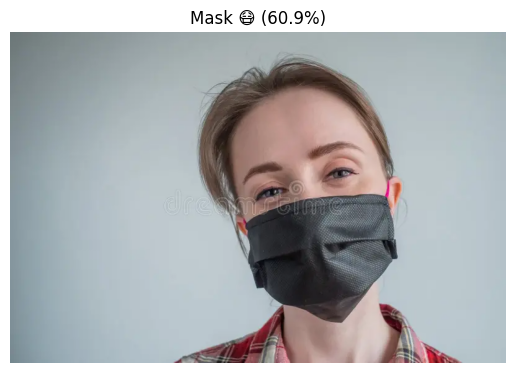

In [46]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/mask_detector.h5')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)

    # Load face detector
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(40,40)
    )

    # =========================
    # CASE 1: NO FACE DETECTED
    # =========================
    if len(faces) == 0:
        print("No face detected → using full image")

        face = cv2.resize(img, (100,100)) / 255.0
        face = np.reshape(face, (1,100,100,3))

        pred = model.predict(face, verbose=0)

        mask_prob = pred[0][0]
        no_mask_prob = pred[0][1]
        confidence = max(mask_prob, no_mask_prob)

        if mask_prob > 0.6:
            label = f"Mask 😷 ({mask_prob*100:.1f}%)"
        elif no_mask_prob > 0.6:
            label = f"No Mask ❌ ({no_mask_prob*100:.1f}%)"
        else:
            label = f"Uncertain 🤔 ({confidence*100:.1f}%)"

        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(label)
        plt.axis('off')
        plt.show()

    # =========================
    # CASE 2: FACE DETECTED
    # =========================
    else:
        for (x,y,w,h) in faces:

            # 🔥 Expand bounding box
            pad = int(0.3 * w)

            x1 = max(0, x - pad)
            y1 = max(0, y - pad)
            x2 = min(img.shape[1], x + w + pad)
            y2 = min(img.shape[0], y + h + pad)

            face = img[y1:y2, x1:x2]

            try:
                face = cv2.resize(face, (100,100)) / 255.0
                face = np.reshape(face, (1,100,100,3))

                pred = model.predict(face, verbose=0)

                mask_prob = pred[0][0]
                no_mask_prob = pred[0][1]
                confidence = max(mask_prob, no_mask_prob)

                if mask_prob > 0.6:
                    label = f"Mask 😷 ({mask_prob*100:.1f}%)"
                    color = (0,255,0)
                elif no_mask_prob > 0.6:
                    label = f"No Mask ❌ ({no_mask_prob*100:.1f}%)"
                    color = (0,0,255)
                else:
                    label = f"Uncertain 🤔 ({confidence*100:.1f}%)"
                    color = (255,165,0)

                # Draw box + label
                cv2.rectangle(img, (x1,y1), (x2,y2), color, 3)
                cv2.putText(img, label, (x1,y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            except:
                pass

        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Final Prediction")
        plt.axis('off')
        plt.show()